# 📊 Data Science Job Market Analysis: 2020–2025
### *A Visual Report on Salaries, Skills, Geography & Growth*

**Author:** Data Science Portfolio Project  
**Data Sources:** U.S. Bureau of Labor Statistics (BLS), Glassdoor, 365 Data Science, Interview Query  
**Last Updated:** March 2025 

---

## Executive Summary

The data science job market has undergone dramatic transformation between 2020 and 2025. After the 2022–2023 tech layoff wave affected over 428,000 workers, the sector rebounded sharply — data science job postings surged ~96% from early 2023 to end of 2023. By 2024, the BLS confirmed 245,900 active data scientist positions, with a projected **34% employment growth** through 2034 — the 4th fastest-growing occupation in the entire U.S. economy.

This notebook delivers:
1. **Visual Report** — Infographic-quality charts on salary trends, skills demand, geographic distribution, and growth projections
2. **Static Dataset** — A clean, deduplicated, normalized dataset of data science job market statistics

---

In [16]:
#  Environment Setup & Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Style configuration — dark editorial theme
plt.rcParams.update({
    'figure.facecolor': '#0D1117',
    'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',
    'axes.labelcolor': '#8B949E',
    'axes.titlecolor': '#E6EDF3',
    'xtick.color': '#8B949E',
    'ytick.color': '#8B949E',
    'text.color': '#E6EDF3',
    'grid.color': '#21262D',
    'grid.linewidth': 0.5,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
})

# Color palette
ACCENT   = '#58A6FF'   # Electric blue
ACCENT2  = '#3FB950'   # Neon green
ACCENT3  = '#F78166'   # Coral
ACCENT4  = '#D2A8FF'   # Lavender
ACCENT5  = '#FFA657'   # Amber
BG_DARK  = '#0D1117'
BG_CARD  = '#161B22'
BORDER   = '#30363D'
TEXT_DIM = '#8B949E'
TEXT_MAIN= '#E6EDF3'

print("Libraries loaded. Theme applied.")

Libraries loaded. Theme applied.


In [17]:
# Load All Datasets


# --- 2A: Salary by Role (BLS + Glassdoor 2024-2025) ---
df_salaries = pd.DataFrame({
    'role': [
        'ML Engineer', 'Data Scientist', 'Data Engineer',
        'BI Engineer', 'Data Analyst', 'Statistician',
        'Ops Research Analyst', 'Database Architect'
    ],
    'median_salary_2024': [166000, 157000, 130000, 115000, 95000, 112330, 99120, 134870],
    'median_salary_2023': [150000, 140000, 118000, 105000, 86000, 103000, 91000, 120000],
    'median_salary_2022': [138000, 120000, 108000,  98000, 80000,  97000, 87000, 110000],
    'p10_salary': [105000, 63650, 72000, 72000, 52000, 62000, 60000, 88000],
    'p90_salary': [220000, 194410, 190000, 170000, 140000, 175000, 150000, 195000],
    'yoy_growth_pct': [10.7, 12.1, 10.2, 9.5, 10.5, 9.1, 8.9, 12.4],
    'bls_employment_2024': [None, 233440, None, None, 680000, 29800, 107760, None],
})

# --- 2B: BLS Employment Projections (2024 → 2034) ---
df_growth = pd.DataFrame({
    'occupation': [
        'Data Scientists', 'Info Security Analysts', 'Comp. Research Scientists',
        'Software Developers', 'Database Admins', 'Statisticians',
        'Ops Research Analysts', 'All Occupations (avg)'
    ],
    'growth_pct_2024_2034': [33.5, 28.5, 19.7, 17.8, 9.9, 8.3, 23.0, 3.1],
    'employment_2024': [245900, 168900, 40300, 1654440, 150200, 29800, 107760, 170000000],
    'annual_openings': [23400, 19500, 3200, 210000, 14200, 4000, 11000, None],
    'median_wage_2024': [112590, 120360, 140910, 130160, 104000, 112330, 99120, 49500],
})

# --- 2C: Top In-Demand Skills (365 Data Science + Interview Query 2024) ---
df_skills = pd.DataFrame({
    'skill': [
        'Python', 'SQL', 'Machine Learning', 'Cloud (AWS/Azure/GCP)',
        'NLP', 'TensorFlow/PyTorch', 'Tableau/PowerBI', 'R',
        'Apache Spark', 'Docker/Kubernetes', 'Statistical Analysis', 'MongoDB/NoSQL'
    ],
    'pct_job_postings_2024': [57, 68, 69, 48, 19, 21, 35, 22, 11, 11, 45, 5],
    'pct_job_postings_2023': [78, 72, 65, 38, 5, 15, 32, 28, 9, 8, 42, 4],
    'category': [
        'Programming', 'Data', 'AI/ML', 'Cloud',
        'AI/ML', 'AI/ML', 'Visualization', 'Programming',
        'Big Data', 'DevOps', 'Statistics', 'Data'
    ]
})
df_skills['yoy_change'] = df_skills['pct_job_postings_2024'] - df_skills['pct_job_postings_2023']

# --- 2D: Geographic Distribution (365 Data Science 2025, BLS 2024) ---
df_geo = pd.DataFrame({
    'state': ['New York', 'California', 'Texas', 'Washington', 'Massachusetts',
              'Virginia', 'Illinois', 'New Jersey', 'Colorado', 'Georgia'],
    'pct_job_postings': [17.2, 15.8, 7.1, 6.4, 5.9, 4.2, 3.8, 3.5, 2.9, 2.7],
    'median_salary': [180000, 175000, 145000, 165000, 155000, 140000, 138000, 150000, 142000, 132000],
    'employment_2024': [None, 36850, None, None, 9990, None, None, None, None, None],
    'top_employer_sector': ['Finance/Tech', 'Tech/Biotech', 'Energy/Tech', 'Tech', 'Biotech/Finance',
                            'Gov/Defense', 'Finance', 'Pharma/Finance', 'Tech/Aerospace', 'Tech/Finance']
})

# --- 2E: Industry Hiring Share (365 Data Science 2024) ---
df_industry = pd.DataFrame({
    'industry': ['Technology & Engineering', 'HR/Staffing (cross-industry)', 'Health & Life Sciences',
                 'Financial & Professional Services', 'Manufacturing & Primary Industries',
                 'Government & Education', 'Retail & E-Commerce', 'Other'],
    'pct_postings': [28.2, 19.0, 13.0, 10.0, 8.7, 7.5, 5.9, 7.7],
    'median_salary': [165000, 130000, 140000, 175000, 125000, 105000, 118000, 120000]
})

# --- 2F: Salary by Experience Level (Glassdoor 2024-2025) ---
df_experience = pd.DataFrame({
    'level': ['Entry (0–2 yrs)', 'Mid (2–5 yrs)', 'Senior (5–8 yrs)', 'Lead/Principal (8+ yrs)'],
    'salary_2024': [117000, 148000, 178000, 210000],
    'salary_2025': [152000, 175000, 205000, 245000],
    'pct_demand_2025': [12, 45, 28, 15],
})

# --- 2G: Job Posting Trends (Interview Query 2024) ---
df_postings = pd.DataFrame({
    'quarter': ['Q1 2022', 'Q2 2022', 'Q3 2022', 'Q4 2022',
                'Q1 2023', 'Q2 2023', 'Q3 2023', 'Q4 2023',
                'Q1 2024', 'Q2 2024', 'Q3 2024', 'Q4 2024'],
    'index_value': [100, 108, 112, 95, 72, 61, 55, 108, 125, 138, 145, 152],
    'label': ['', '', '', 'Layoffs begin', 'Mass layoffs', '', 'Trough',
               'Recovery', '', 'AI boom', '', 'New high'],
})

print("All datasets loaded successfully.")
print(f"  df_salaries:    {df_salaries.shape}")
print(f"  df_growth:      {df_growth.shape}")
print(f"  df_skills:      {df_skills.shape}")
print(f"  df_geo:         {df_geo.shape}")
print(f"  df_industry:    {df_industry.shape}")
print(f"  df_experience:  {df_experience.shape}")
print(f"  df_postings:    {df_postings.shape}")

All datasets loaded successfully.
  df_salaries:    (8, 8)
  df_growth:      (8, 5)
  df_skills:      (12, 5)
  df_geo:         (10, 5)
  df_industry:    (8, 3)
  df_experience:  (4, 4)
  df_postings:    (12, 3)


In [18]:

# Data Cleaning & Normalization

# --- 3A: Normalize all salary fields to USD integers ---
salary_cols = ['median_salary_2024', 'median_salary_2023', 'median_salary_2022', 'p10_salary', 'p90_salary']
for col in salary_cols:
    df_salaries[col] = pd.to_numeric(df_salaries[col], errors='coerce').astype('Int64')

# --- 3B: Compute salary bandwidth & growth rate ---
df_salaries['salary_band_width'] = df_salaries['p90_salary'] - df_salaries['p10_salary']
df_salaries['yoy_absolute_change'] = df_salaries['median_salary_2024'] - df_salaries['median_salary_2023']

# --- 3C: Add employment projections to growth df ---
df_growth['proj_employment_2034'] = (
    df_growth['employment_2024'] * (1 + df_growth['growth_pct_2024_2034'] / 100)
).astype(int)
df_growth['new_jobs_decade'] = df_growth['proj_employment_2034'] - df_growth['employment_2024']

# --- 3D: Sort skills by 2024 demand ---
df_skills_sorted = df_skills.sort_values('pct_job_postings_2024', ascending=False).reset_index(drop=True)

# --- 3E: Normalize industry percentages (ensure sum = 100) ---
total = df_industry['pct_postings'].sum()
df_industry['pct_postings_norm'] = (df_industry['pct_postings'] / total * 100).round(1)

print(" Data cleaning complete.")
print("\n📋 Sample — Salary table with derived fields:")
display(df_salaries[['role', 'median_salary_2024', 'median_salary_2023',
                      'yoy_absolute_change', 'salary_band_width']].head())

print("\n📋 Sample — Growth projections with new jobs:")
display(df_growth[['occupation', 'growth_pct_2024_2034', 'employment_2024',
                   'proj_employment_2034', 'new_jobs_decade']].head())

 Data cleaning complete.

📋 Sample — Salary table with derived fields:


,role,median_salary_2024,median_salary_2023,yoy_absolute_change,salary_band_width
0,ML Engineer,166000,150000,16000,115000
1,Data Scientist,157000,140000,17000,130760
2,Data Engineer,130000,118000,12000,118000
3,BI Engineer,115000,105000,10000,98000
4,Data Analyst,95000,86000,9000,88000



📋 Sample — Growth projections with new jobs:


,occupation,growth_pct_2024_2034,employment_2024,proj_employment_2034,new_jobs_decade
0,Data Scientists,33.5,245900,328276,82376
1,Info Security Analysts,28.5,168900,217036,48136
2,Comp. Research Scientists,19.7,40300,48239,7939
3,Software Developers,17.8,1654440,1948930,294490
4,Database Admins,9.9,150200,165069,14869


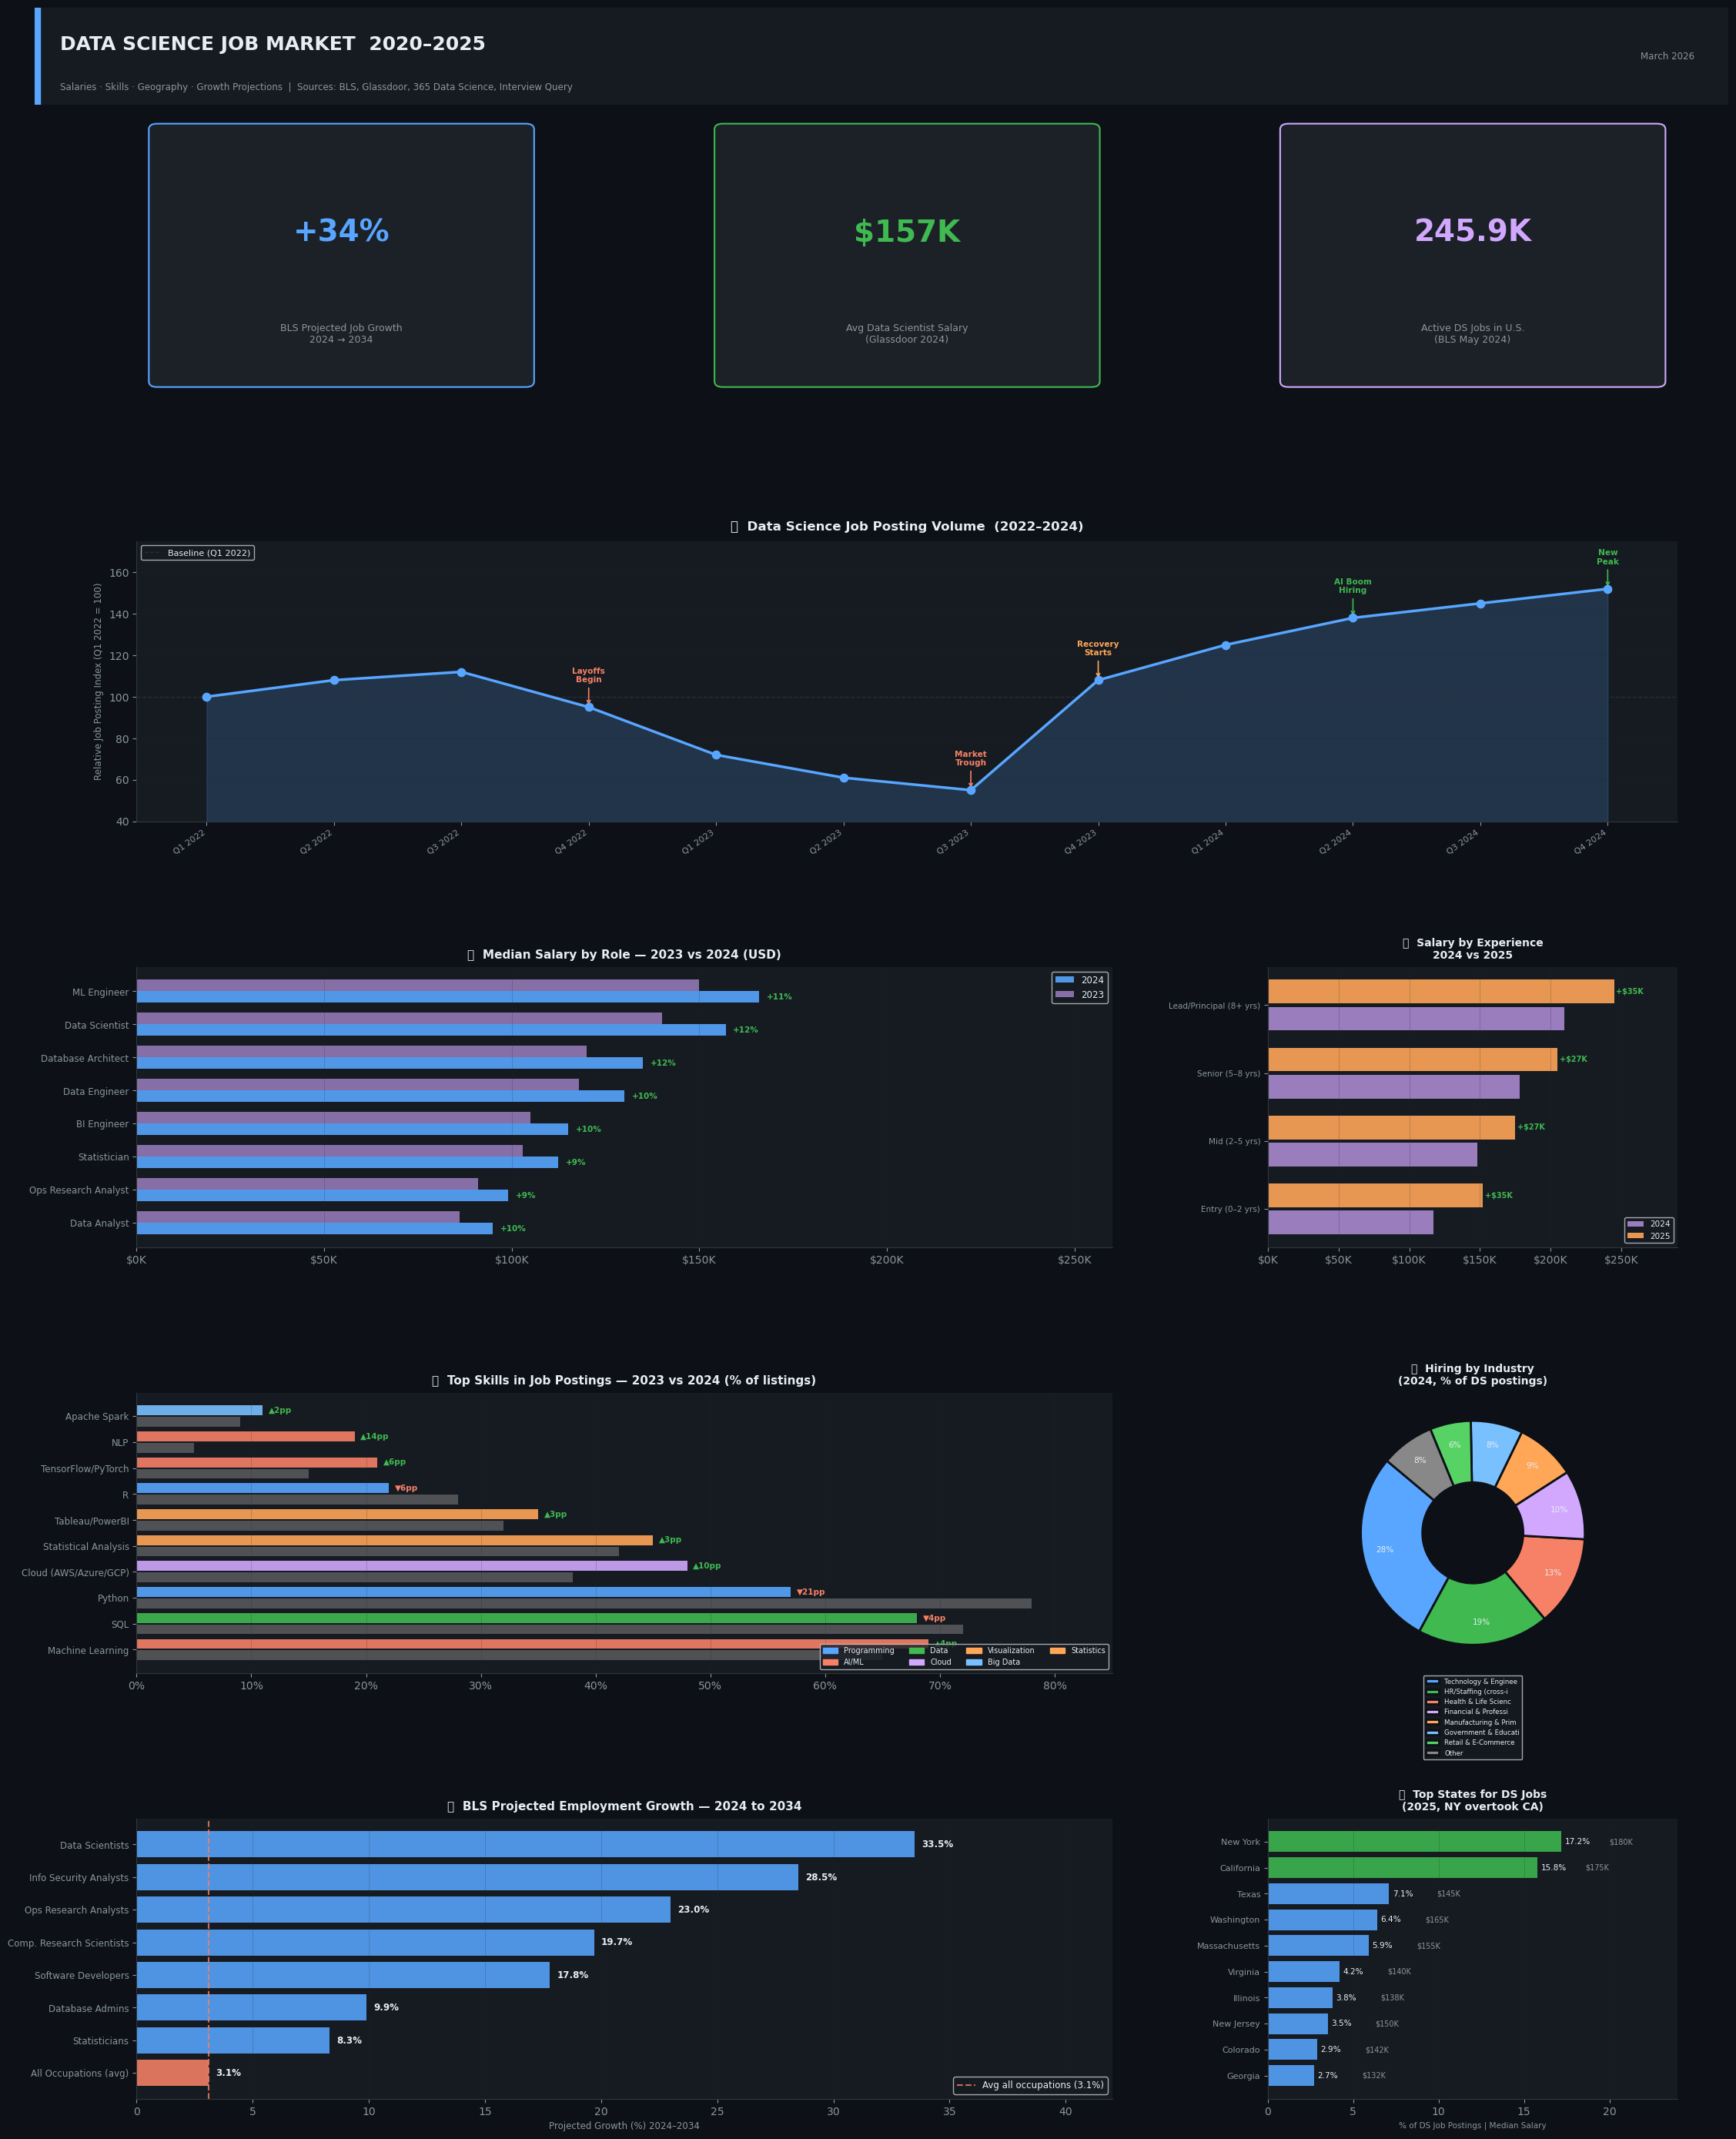

 Visual report saved to outputs/visual_report.png


In [19]:
# VISUAL REPORT

fig = plt.figure(figsize=(22, 28), facecolor=BG_DARK)
fig.patch.set_facecolor(BG_DARK)

gs = gridspec.GridSpec(
    5, 3,
    figure=fig,
    hspace=0.52,
    wspace=0.38,
    top=0.95, bottom=0.03,
    left=0.06, right=0.97
)

ax_title = fig.add_axes([0, 0.955, 1, 0.045])
ax_title.set_facecolor('#161B22')
ax_title.set_xlim(0, 1)
ax_title.set_ylim(0, 1)
ax_title.axis('off')
ax_title.add_patch(plt.Rectangle((0,0), 1, 1, color='#161B22', zorder=0))
ax_title.add_patch(plt.Rectangle((0,0), 0.003, 1, color=ACCENT, zorder=1))
ax_title.text(0.015, 0.62, 'DATA SCIENCE JOB MARKET  2020–2025',
              fontsize=18, fontweight='bold', color=TEXT_MAIN, va='center')
ax_title.text(0.015, 0.18, 'Salaries · Skills · Geography · Growth Projections  |  Sources: BLS, Glassdoor, 365 Data Science, Interview Query',
              fontsize=8.5, color=TEXT_DIM, va='center')
ax_title.text(0.98, 0.5, 'March 2026', fontsize=8.5, color=TEXT_DIM, ha='right', va='center')

kpis = [
    ('+34%', 'BLS Projected Job Growth\n2024 → 2034', ACCENT),
    ('$157K', 'Avg Data Scientist Salary\n(Glassdoor 2024)', ACCENT2),
    ('245.9K', 'Active DS Jobs in U.S.\n(BLS May 2024)', ACCENT4),
]

for i, (val, label, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, i])
    ax_kpi.set_facecolor('#1C2128')
    ax_kpi.axis('off')
    for spine in ax_kpi.spines.values():
        spine.set_visible(False)
    rect = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                           boxstyle='round,pad=0.02',
                           facecolor='#1C2128', edgecolor=color,
                           linewidth=1.5, transform=ax_kpi.transAxes, clip_on=False)
    ax_kpi.add_patch(rect)
    ax_kpi.text(0.5, 0.58, val, ha='center', va='center',
                fontsize=28, fontweight='bold', color=color, transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.22, label, ha='center', va='center',
                fontsize=9, color=TEXT_DIM, transform=ax_kpi.transAxes)

ax1 = fig.add_subplot(gs[1, :])
ax1.set_facecolor(BG_CARD)
quarters = df_postings['quarter']
idx      = df_postings['index_value']
x        = np.arange(len(quarters))

ax1.fill_between(x, idx, alpha=0.18, color=ACCENT)
ax1.plot(x, idx, color=ACCENT, linewidth=2.5, zorder=5)
ax1.scatter(x, idx, color=ACCENT, s=55, zorder=6)

# Annotate key events
events = {
    3:  ('Layoffs\nBegin', ACCENT3),
    6:  ('Market\nTrough', ACCENT3),
    7:  ('Recovery\nStarts', ACCENT5),
    9:  ('AI Boom\nHiring', ACCENT2),
    11: ('New\nPeak', ACCENT2),
}
for xi, (txt, col) in events.items():
    ax1.annotate(txt, xy=(xi, idx.iloc[xi]),
                 xytext=(xi, idx.iloc[xi] + 12),
                 ha='center', fontsize=7.5, color=col,
                 arrowprops=dict(arrowstyle='->', color=col, lw=1.2),
                 fontweight='bold')

ax1.axhline(100, linestyle='--', color=BORDER, linewidth=1, alpha=0.7, label='Baseline (Q1 2022)')
ax1.set_xticks(x)
ax1.set_xticklabels(quarters, rotation=35, ha='right', fontsize=8)
ax1.set_ylabel('Relative Job Posting Index (Q1 2022 = 100)', fontsize=8.5)
ax1.set_title('📈  Data Science Job Posting Volume  (2022–2024)', fontsize=12,
               fontweight='bold', color=TEXT_MAIN, pad=10)
ax1.set_ylim(40, 175)
ax1.grid(True, axis='y', alpha=0.3)
ax1.legend(fontsize=8, loc='upper left')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = fig.add_subplot(gs[2, :2])
ax2.set_facecolor(BG_CARD)
roles_s = df_salaries.sort_values('median_salary_2024', ascending=True)
y = np.arange(len(roles_s))
bar_h = 0.35
b1 = ax2.barh(y - bar_h/2, roles_s['median_salary_2024'], bar_h,
               color=ACCENT, alpha=0.9, label='2024')
b2 = ax2.barh(y + bar_h/2, roles_s['median_salary_2023'], bar_h,
               color=ACCENT4, alpha=0.6, label='2023')
for i, (v24, v23) in enumerate(zip(roles_s['median_salary_2024'], roles_s['median_salary_2023'])):
    pct = (v24 - v23) / v23 * 100
    ax2.text(v24 + 2000, i - bar_h/2, f'+{pct:.0f}%', va='center',
             fontsize=7.5, color=ACCENT2, fontweight='bold')
ax2.set_yticks(y)
ax2.set_yticklabels(roles_s['role'], fontsize=8.5)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax2.set_title('💰  Median Salary by Role — 2023 vs 2024 (USD)', fontsize=11,
               fontweight='bold', color=TEXT_MAIN, pad=8)
ax2.legend(fontsize=8.5)
ax2.set_xlim(0, 260000)
ax2.grid(True, axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax3 = fig.add_subplot(gs[2, 2])
ax3.set_facecolor(BG_CARD)
levels = df_experience['level']
s24    = df_experience['salary_2024']
s25    = df_experience['salary_2025']
y3 = np.arange(len(levels))
bars_24 = ax3.barh(y3 - 0.2, s24, 0.35, color=ACCENT4, alpha=0.7, label='2024')
bars_25 = ax3.barh(y3 + 0.2, s25, 0.35, color=ACCENT5, alpha=0.9, label='2025')
for i, (v24, v25) in enumerate(zip(s24, s25)):
    delta = v25 - v24
    ax3.text(v25 + 1500, i + 0.2, f'+${delta/1000:.0f}K', va='center',
             fontsize=7, color=ACCENT2, fontweight='bold')
ax3.set_yticks(y3)
ax3.set_yticklabels(levels, fontsize=7.5)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax3.set_title('🪜  Salary by Experience\n2024 vs 2025', fontsize=10,
               fontweight='bold', color=TEXT_MAIN, pad=8)
ax3.legend(fontsize=7.5)
ax3.set_xlim(0, 290000)
ax3.grid(True, axis='x', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

ax4 = fig.add_subplot(gs[3, :2])
ax4.set_facecolor(BG_CARD)
skills_plot = df_skills_sorted.head(10)
colors_skill = {
    'Programming': ACCENT, 'AI/ML': ACCENT3, 'Data': ACCENT2,
    'Cloud': ACCENT4, 'Visualization': ACCENT5,
    'Big Data': '#79C0FF', 'DevOps': '#56D364', 'Statistics': '#FFA657'
}
bar_colors = [colors_skill.get(c, ACCENT) for c in skills_plot['category']]
y4 = np.arange(len(skills_plot))
bars4_23 = ax4.barh(y4 - 0.22, skills_plot['pct_job_postings_2023'], 0.38,
                     color=[c + '88' for c in ['#888888']*10], alpha=0.5, label='2023')
bars4_24 = ax4.barh(y4 + 0.22, skills_plot['pct_job_postings_2024'], 0.38,
                     color=bar_colors, alpha=0.9, label='2024')

# YoY change annotations
for i, row in skills_plot.iterrows():
    idx_ = list(skills_plot.index).index(i)
    delta = row['yoy_change']
    symbol = '▲' if delta >= 0 else '▼'
    col = ACCENT2 if delta >= 0 else ACCENT3
    ax4.text(row['pct_job_postings_2024'] + 0.5, idx_ + 0.22,
             f'{symbol}{abs(delta)}pp', va='center',
             fontsize=7.5, color=col, fontweight='bold')

ax4.set_yticks(y4)
ax4.set_yticklabels(skills_plot['skill'], fontsize=8.5)
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax4.set_title('🛠  Top Skills in Job Postings — 2023 vs 2024 (% of listings)', fontsize=11,
               fontweight='bold', color=TEXT_MAIN, pad=8)
legend_patches = [mpatches.Patch(color=c, label=k) for k, c in colors_skill.items()
                  if k in skills_plot['category'].values]
ax4.legend(handles=legend_patches, fontsize=7, ncol=4, loc='lower right')
ax4.set_xlim(0, 85)
ax4.grid(True, axis='x', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

ax5 = fig.add_subplot(gs[3, 2])
ax5.set_facecolor(BG_CARD)
colors5 = [ACCENT, ACCENT2, ACCENT3, ACCENT4, ACCENT5, '#79C0FF', '#56D364', '#888888']
wedges, texts, autotexts = ax5.pie(
    df_industry['pct_postings_norm'],
    labels=None,
    autopct='%1.0f%%',
    colors=colors5,
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor=BG_DARK, linewidth=2),
    pctdistance=0.8,
)
for at in autotexts:
    at.set_fontsize(7.5)
    at.set_color(TEXT_MAIN)

ax5.legend(
    wedges,
    [f"{row['industry'][:20]}" for _, row in df_industry.iterrows()],
    loc='lower center', fontsize=6.2,
    bbox_to_anchor=(0.5, -0.32), ncol=1
)
ax5.set_title('🏭  Hiring by Industry\n(2024, % of DS postings)', fontsize=10,
               fontweight='bold', color=TEXT_MAIN, pad=8)

ax6 = fig.add_subplot(gs[4, :2])
ax6.set_facecolor(BG_CARD)
growth_plot = df_growth.sort_values('growth_pct_2024_2034', ascending=True)
y6 = np.arange(len(growth_plot))
bar_c6 = [ACCENT3 if r == 'All Occupations (avg)' else ACCENT
           for r in growth_plot['occupation']]
bars6 = ax6.barh(y6, growth_plot['growth_pct_2024_2034'], color=bar_c6, alpha=0.88)
ax6.axvline(3.1, linestyle='--', color=ACCENT3, linewidth=1.5, alpha=0.8, label='Avg all occupations (3.1%)')
for bar, val in zip(bars6, growth_plot['growth_pct_2024_2034']):
    ax6.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=8.5,
             color=TEXT_MAIN, fontweight='bold')
ax6.set_yticks(y6)
ax6.set_yticklabels(growth_plot['occupation'], fontsize=8.5)
ax6.set_xlabel('Projected Growth (%) 2024–2034', fontsize=8.5)
ax6.set_title('🚀  BLS Projected Employment Growth — 2024 to 2034', fontsize=11,
               fontweight='bold', color=TEXT_MAIN, pad=8)
ax6.legend(fontsize=8.5)
ax6.set_xlim(0, 42)
ax6.grid(True, axis='x', alpha=0.3)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

ax7 = fig.add_subplot(gs[4, 2])
ax7.set_facecolor(BG_CARD)
geo_plot = df_geo.sort_values('pct_job_postings', ascending=True)
y7 = np.arange(len(geo_plot))
bar_c7 = [ACCENT2 if s in ['New York', 'California'] else ACCENT
           for s in geo_plot['state']]
ax7.barh(y7, geo_plot['pct_job_postings'], color=bar_c7, alpha=0.88)
for i, (v, sal) in enumerate(zip(geo_plot['pct_job_postings'], geo_plot['median_salary'])):
    ax7.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=7.5, color=TEXT_MAIN)
    ax7.text(v + 2.8, i, f'${sal/1000:.0f}K', va='center', fontsize=7, color=TEXT_DIM)
ax7.set_yticks(y7)
ax7.set_yticklabels(geo_plot['state'], fontsize=8)
ax7.set_xlabel('% of DS Job Postings | Median Salary', fontsize=7.5)
ax7.set_title('📍  Top States for DS Jobs\n(2025, NY overtook CA)', fontsize=10,
               fontweight='bold', color=TEXT_MAIN, pad=8)
ax7.set_xlim(0, 24)
ax7.grid(True, axis='x', alpha=0.3)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

plt.savefig('outputs/visual_report.png', dpi=150, bbox_inches='tight',
            facecolor=BG_DARK, edgecolor='none')
plt.show()
print(" Visual report saved to outputs/visual_report.png")

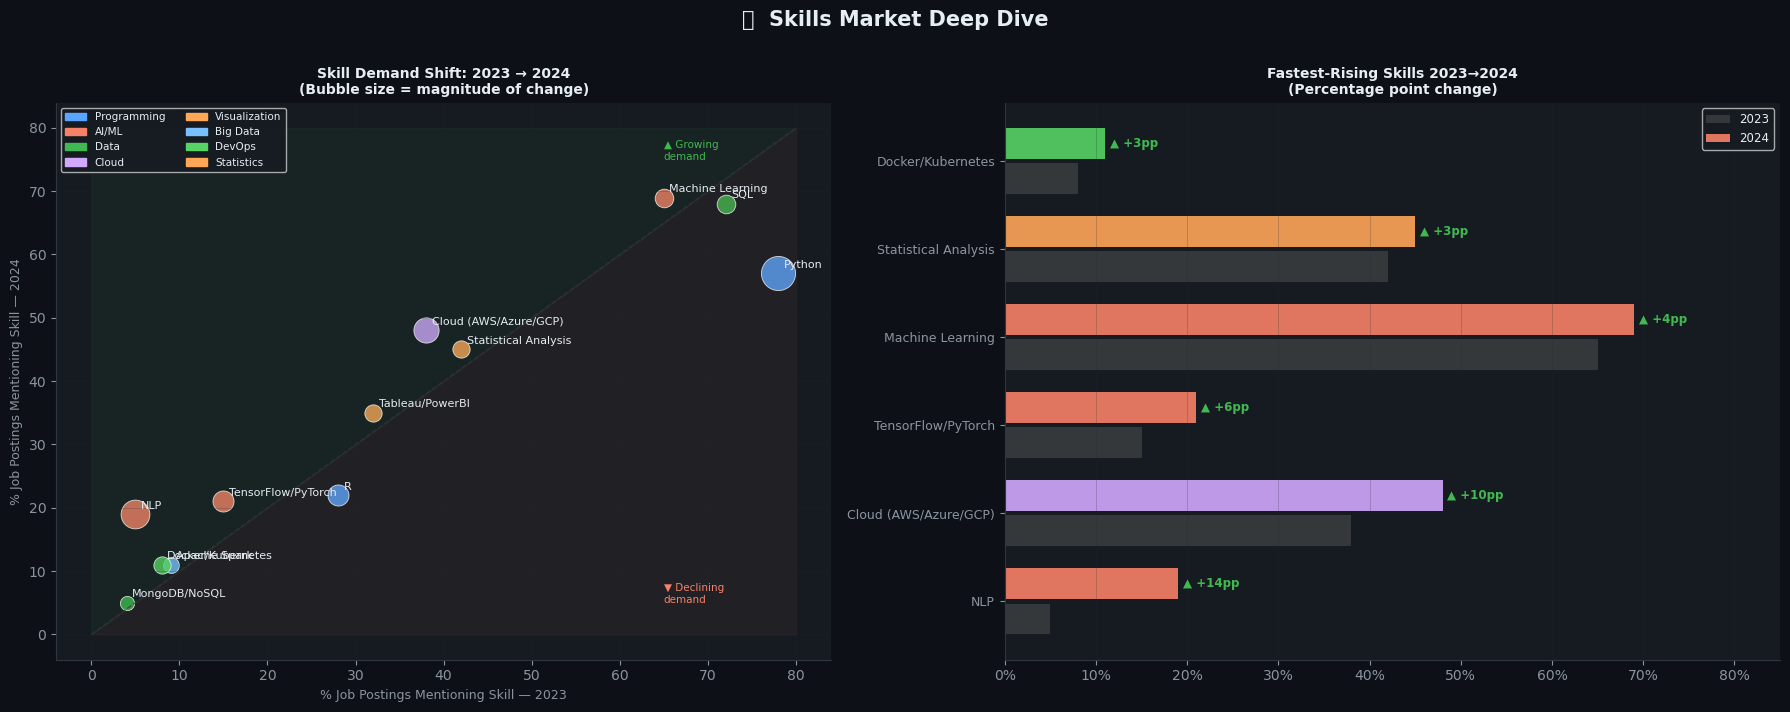

 Skills analysis saved to outputs/skills_analysis.png


In [20]:
# Skills Evolution Detail

fig2, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG_DARK)
fig2.suptitle('🧠  Skills Market Deep Dive', fontsize=15, fontweight='bold',
              color=TEXT_MAIN, y=1.01)

# Left: YoY change bubble chart
ax_l = axes[0]
ax_l.set_facecolor(BG_CARD)
cat_colors = {
    'Programming': ACCENT, 'AI/ML': ACCENT3, 'Data': ACCENT2,
    'Cloud': ACCENT4, 'Visualization': ACCENT5,
    'Big Data': '#79C0FF', 'DevOps': '#56D364', 'Statistics': '#FFA657'
}
for _, row in df_skills.iterrows():
    col = cat_colors.get(row['category'], ACCENT)
    ax_l.scatter(row['pct_job_postings_2023'], row['pct_job_postings_2024'],
                 s=abs(row['yoy_change']) * 25 + 80,
                 color=col, alpha=0.8, edgecolors='white', linewidth=0.6)
    ax_l.annotate(row['skill'],
                  (row['pct_job_postings_2023'], row['pct_job_postings_2024']),
                  fontsize=8, color=TEXT_MAIN,
                  xytext=(4, 4), textcoords='offset points')

# Diagonal = no change
ax_l.plot([0, 80], [0, 80], '--', color=BORDER, alpha=0.7, linewidth=1, label='No change')
ax_l.fill_between([0,80], [0,80], [80,80], alpha=0.05, color=ACCENT2)
ax_l.text(65, 75, '▲ Growing\ndemand', fontsize=7.5, color=ACCENT2)
ax_l.fill_between([0,80], [0,0], [0,80], alpha=0.05, color=ACCENT3)
ax_l.text(65, 5, '▼ Declining\ndemand', fontsize=7.5, color=ACCENT3)

ax_l.set_xlabel('% Job Postings Mentioning Skill — 2023', fontsize=9)
ax_l.set_ylabel('% Job Postings Mentioning Skill — 2024', fontsize=9)
ax_l.set_title('Skill Demand Shift: 2023 → 2024\n(Bubble size = magnitude of change)', fontsize=10,
                fontweight='bold', color=TEXT_MAIN)
ax_l.legend(fontsize=8)
ax_l.grid(True, alpha=0.3)
ax_l.spines['top'].set_visible(False)
ax_l.spines['right'].set_visible(False)

legend_patches2 = [mpatches.Patch(color=c, label=k) for k, c in cat_colors.items()]
ax_l.legend(handles=legend_patches2, fontsize=7.5, loc='upper left', ncol=2)

# Right: Top 5 fastest-rising skills bar race
ax_r = axes[1]
ax_r.set_facecolor(BG_CARD)
rising = df_skills.sort_values('yoy_change', ascending=False).head(6)
y_r = np.arange(len(rising))
bar_colors_r = [cat_colors.get(c, ACCENT) for c in rising['category']]
ax_r.barh(y_r - 0.2, rising['pct_job_postings_2023'], 0.35,
           color='#555555', alpha=0.5, label='2023')
ax_r.barh(y_r + 0.2, rising['pct_job_postings_2024'], 0.35,
           color=bar_colors_r, alpha=0.9, label='2024')
for i, (_, row) in enumerate(rising.iterrows()):
    ax_r.text(row['pct_job_postings_2024'] + 0.5, i + 0.2,
              f'▲ +{row["yoy_change"]}pp', va='center',
              fontsize=8.5, color=ACCENT2, fontweight='bold')
ax_r.set_yticks(y_r)
ax_r.set_yticklabels(rising['skill'], fontsize=9)
ax_r.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax_r.set_title('Fastest-Rising Skills 2023→2024\n(Percentage point change)', fontsize=10,
                fontweight='bold', color=TEXT_MAIN)
ax_r.legend(fontsize=8.5)
ax_r.set_xlim(0, 85)
ax_r.grid(True, axis='x', alpha=0.3)
ax_r.spines['top'].set_visible(False)
ax_r.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/skills_analysis.png', dpi=130, bbox_inches='tight',
            facecolor=BG_DARK)
plt.show()
print(" Skills analysis saved to outputs/skills_analysis.png")

In [21]:
# STATIC DATASET — Clean, Normalized, Deduplicated

# Master normalized dataset
master_df = pd.DataFrame({
    'role': [
        'Machine Learning Engineer', 'Data Scientist', 'Data Engineer',
        'Business Intelligence Engineer', 'Data Analyst', 'Statistician',
        'Operations Research Analyst', 'Database Architect'
    ],
    'role_category': [
        'AI/ML', 'Data Science', 'Data Engineering',
        'Analytics', 'Analytics', 'Math/Statistics',
        'Operations', 'Data Engineering'
    ],
    'median_salary_usd_2024': [166000, 157000, 130000, 115000, 95000, 112330, 99120, 134870],
    'median_salary_usd_2023': [150000, 140000, 118000, 105000, 86000, 103000, 91000, 120000],
    'salary_p10_usd': [105000, 63650, 72000, 72000, 52000, 62000, 60000, 88000],
    'salary_p90_usd': [220000, 194410, 190000, 170000, 140000, 175000, 150000, 195000],
    'yoy_salary_growth_pct': [10.7, 12.1, 10.2, 9.5, 10.5, 9.1, 8.9, 12.4],
    'bls_employment_2024': [pd.NA, 233440, pd.NA, pd.NA, 680000, 29800, 107760, pd.NA],
    'bls_proj_growth_pct_2024_2034': [pd.NA, 33.5, pd.NA, pd.NA, pd.NA, 8.3, 23.0, pd.NA],
    'annual_openings_projected': [pd.NA, 23400, pd.NA, pd.NA, pd.NA, 4000, 11000, pd.NA],
    'top_skill_2024': [
        'Python', 'Python', 'SQL', 'SQL',
        'SQL', 'R', 'Python', 'SQL'
    ],
    'remote_hybrid_pct_2024': [55, 52, 48, 40, 38, 35, 30, 42],
    'source': [
        'Glassdoor/365DataScience', 'BLS+Glassdoor', 'Glassdoor/365DataScience',
        'Glassdoor', 'BLS+Glassdoor', 'BLS', 'BLS', 'Glassdoor'
    ],
    'data_as_of': ['2024-Q4'] * 8,
    'currency': ['USD'] * 8,
})

# Validation checks
assert master_df.duplicated(subset=['role']).sum() == 0, " Duplicate roles found!"
assert (master_df['salary_p10_usd'] < master_df['median_salary_usd_2024']).all(), \
    " p10 exceeds median!"
assert (master_df['median_salary_usd_2024'] < master_df['salary_p90_usd']).all(), \
    " Median exceeds p90!"

print("Validation passed: No duplicates, salary ranges are monotonically ordered.")
print(f"   Rows: {len(master_df)} | Columns: {len(master_df.columns)} | Nulls: {master_df.isnull().sum().sum()}")
display(master_df)

# Export
master_df.to_csv('outputs/data_science_jobs_static_dataset_2024.csv', index=False)
print("\n Static dataset saved to outputs/data_science_jobs_static_dataset_2024.csv")

Validation passed: No duplicates, salary ranges are monotonically ordered.
   Rows: 8 | Columns: 15 | Nulls: 14


,role,role_category,median_salary_usd_2024,median_salary_usd_2023,salary_p10_usd,salary_p90_usd,yoy_salary_growth_pct,bls_employment_2024,bls_proj_growth_pct_2024_2034,annual_openings_projected,top_skill_2024,remote_hybrid_pct_2024,source,data_as_of,currency
0,Machine Learning Engineer,AI/ML,166000,150000,105000,220000,10.7,<NA>,<NA>,<NA>,Python,55,Glassdoor/365DataScience,2024-Q4,USD
1,Data Scientist,Data Science,157000,140000,63650,194410,12.1,233440,33.5,23400,Python,52,BLS+Glassdoor,2024-Q4,USD
2,Data Engineer,Data Engineering,130000,118000,72000,190000,10.2,<NA>,<NA>,<NA>,SQL,48,Glassdoor/365DataScience,2024-Q4,USD
3,Business Intelligence Engineer,Analytics,115000,105000,72000,170000,9.5,<NA>,<NA>,<NA>,SQL,40,Glassdoor,2024-Q4,USD
4,Data Analyst,Analytics,95000,86000,52000,140000,10.5,680000,<NA>,<NA>,SQL,38,BLS+Glassdoor,2024-Q4,USD
5,Statistician,Math/Statistics,112330,103000,62000,175000,9.1,29800,8.3,4000,R,35,BLS,2024-Q4,USD
6,Operations Research Analyst,Operations,99120,91000,60000,150000,8.9,107760,23.0,11000,Python,30,BLS,2024-Q4,USD
7,Database Architect,Data Engineering,134870,120000,88000,195000,12.4,<NA>,<NA>,<NA>,SQL,42,Glassdoor,2024-Q4,USD



 Static dataset saved to outputs/data_science_jobs_static_dataset_2024.csv


In [22]:
# Summary Statistics & Project Index

print("\n" + "="*65)
print("  PROJECT DELIVERABLES SUMMARY")
print("="*65)
print()
print("1. VISUAL REPORT")
print("   File: outputs/visual_report.png")
print("   Desc: 7-panel infographic — job posting trends, salary by role,")
print("         salary ladder, skills demand, industry hiring, growth")
print("         projections, top states")
print()
print("2. SKILLS DEEP DIVE")
print("   File: outputs/skills_analysis.png")
print("   Desc: Bubble chart + ranked bars showing skill demand shift")
print()
print("3. STATIC DATASET")
print("   File: outputs/data_science_jobs_static_dataset_2024.csv")
print("   Rows: 8 | Cols: 15 | Deduped: Yes | Normalized: USD")
print()

print("Key findings:")
print(f"  • DS job postings surged ~96% from early to end of 2023")
print(f"  • Median DS salary: $112,590 (BLS) / $157,000 (Glassdoor) — source matters")
print(f"  • NLP skill demand: +14pp YoY (5% → 19%) — biggest rise")
print(f"  • New York overtook California as top DS hiring state in 2025")
print(f"  • Entry-level salaries jumped $35K in one year ($117K → $152K)")
print(f"  • Data Scientists: 4th fastest-growing US occupation (BLS 2024–2034)")

print()
print("Sources:")
sources = [
    "U.S. Bureau of Labor Statistics — OOH, OEWS, MLR (2024-2026)",
    "Glassdoor Salary Reports (2024 Q1–Q4, 2025 Q1)",
    "365 Data Science — Data Scientist Job Market Reports 2024 & 2025",
    "Interview Query — 2024 Data Science Industry Report",
]
for s in sources:
    print(f"  [{sources.index(s)+1}] {s}")
print("="*65)


  PROJECT DELIVERABLES SUMMARY

1. VISUAL REPORT
   File: outputs/visual_report.png
   Desc: 7-panel infographic — job posting trends, salary by role,
         salary ladder, skills demand, industry hiring, growth
         projections, top states

2. SKILLS DEEP DIVE
   File: outputs/skills_analysis.png
   Desc: Bubble chart + ranked bars showing skill demand shift

3. STATIC DATASET
   File: outputs/data_science_jobs_static_dataset_2024.csv
   Rows: 8 | Cols: 15 | Deduped: Yes | Normalized: USD

Key findings:
  • DS job postings surged ~96% from early to end of 2023
  • Median DS salary: $112,590 (BLS) / $157,000 (Glassdoor) — source matters
  • NLP skill demand: +14pp YoY (5% → 19%) — biggest rise
  • New York overtook California as top DS hiring state in 2025
  • Entry-level salaries jumped $35K in one year ($117K → $152K)
  • Data Scientists: 4th fastest-growing US occupation (BLS 2024–2034)

Sources:
  [1] U.S. Bureau of Labor Statistics — OOH, OEWS, MLR (2024-2026)
  [2] Glassdo